In [2]:
import pandas as pd
import numpy as np
from scipy.stats import t
import matplotlib.pyplot as plt


# Reading in the Advertising Data

In [3]:
df = pd.read_csv('../Homework_Data/Advertising.csv', index_col=0)

## Carrying Analysis on TV (Feature) and Sales (Predictor) columns

In [4]:
#grabbing the data
x = df['TV'].values
y = df['sales'].values

In [5]:
#Generating functions to use in the analysis 

def model(x, beta0, beta1):
    
    '''
    Function that does a linear model with y-intercept beta0 and slope beta1
    '''

    return beta0 + beta1 * x

def RSS(x, y, beta0, beta1):
    '''
    Function that computes the Residual Sum of Squares(RSS). A metric that tells you how well fit the model is to the data
    '''

    return np.sum((y - model(x, beta0, beta1))**2)

def minimum_beta1(x, y):

    '''
    Function to compute the beta1 that minimizes the loss function
    '''

    x_mean = x.mean()
    y_mean = y.mean()
    beta1 = sum((x - x_mean) * (y - y_mean)) / sum((x - x_mean)**2)
    return beta1

def minimum_beta0(x, y, beta1):

    '''
    Function that computes the beta0 that minimizes the loss function 
    '''

    return y.mean() - beta1 * x.mean()

def standard_error_beta0(x, y, beta0, beta1):
    n = len(x)

    residuals = y - (beta1*x + beta0)
    sigma2 = np.sum(residuals**2) / (n - 2)

    Sxx = np.sum((x - np.mean(x))**2)

    var_beta0 = sigma2 * (1/n + (np.mean(x)**2)/Sxx)

    return np.sqrt(var_beta0)


def standard_error_beta1(x, y, beta0, beta1):
    n = len(x)

    residuals = y - (beta1*x + beta0)
    sigma2 = np.sum(residuals**2) / (n - 2)

    Sxx = np.sum((x - np.mean(x))**2)

    var_beta1 = sigma2 / Sxx

    return np.sqrt(var_beta1)

def confidence_interval(beta, SE):

    '''
    Function that computes the confidence interval given a beta and the standard error on that beta
    '''

    return (beta - 2*SE, beta + 2*SE)

def t_test(beta, SE):
    
    return beta/SE


def p_value(t_score, n):

    return 1 - t.cdf(t_score, n-2)

In [6]:
def main(x, y):

    '''
    Function that merges all the previous functions into one main function to then call and compute
    relevant quanitites for the fitting
    '''
    
    n = len(x)
    
    beta1 = minimum_beta1(x, y)
    beta0 = minimum_beta0(x, y, beta1)
    
    SE_beta0 = standard_error_beta0(x, y, beta0, beta1)
    SE_beta1 = standard_error_beta1(x, y, beta0, beta1)

    CI_beta0 = confidence_interval(beta0, SE_beta0)
    CI_beta1 = confidence_interval(beta1, SE_beta1)

    t_beta0 = t_test(beta0, SE_beta0)
    t_beta1 = t_test(beta1, SE_beta1)

    p_beta0 = p_value(t_beta0, n)
    p_beta1 = p_value(t_beta1, n)

    print(f'beta0: {beta0:.4f} +/- {SE_beta0:.4f}, p-value: {p_beta0:.4f}')
    print(f'beta1: {beta1:.4f} +/-  {SE_beta1:.4f}, p-value: {p_beta1:.4f}')

    return beta0, beta1, SE_beta0, SE_beta1, CI_beta0, CI_beta1, t_beta0, t_beta1, p_beta0, p_beta1


In [7]:
beta0, beta1, SE_beta0, SE_beta1, CI_beta0, CI_beta1, t_beta0, t_beta1, p_beta0, p_beta1 = main(x, y)

beta0: 7.0326 +/- 0.4578, p-value: 0.0000
beta1: 0.0475 +/-  0.0027, p-value: 0.0000


beta0: 7.0326 +/- 0.4578, p-value: 0.0000
beta1: 0.0475 +/-  0.0027, p-value: 0.0000


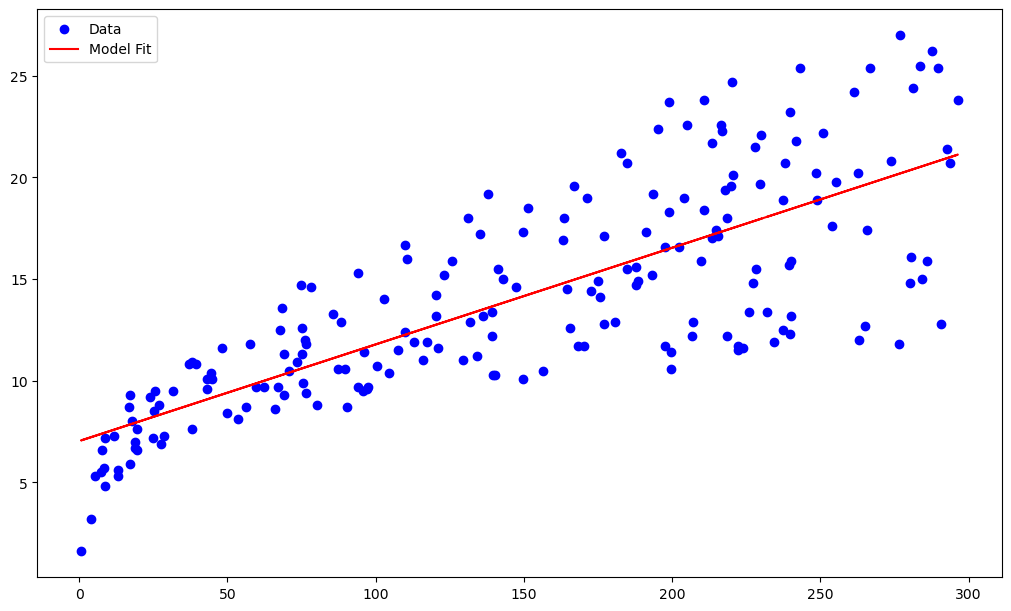

In [8]:
fig, ax = plt.subplots(figsize = (10, 6), constrained_layout=True)
ax.scatter(x, y, color='blue', label = 'Data')
ax.plot(x, model(x, *main(x, y)[:2]), color='red', label = 'Model Fit')
ax.legend()
plt.show()

# Chapter 2 Lab: ANOVA Analysis

In [9]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels .stats.anova import anova_lm
from ISLP.models import ( ModelSpec as MS ,
                          summarize ,
                          poly)
from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF

In [10]:
def construct_X_array(df, features_cols):
    design = MS(features_cols)
    X = design.fit_transform(df)
    return X

def run_linear_model(df, features_cols, target_col):
    X = construct_X_array(df, features_cols)
    y = df[target_col]
    model = sm.OLS(y, X)
    results = model.fit()

    return results

def plot_residuals(results):
    residual = results.resid
    xaxis = np.arange(len(residual))
    
    fig, ax = plt.subplots(*args, **kwargs)
    ax.scatter(xaxis, residual, *args, *kwargs)
    ax.axhline(0, color='red', lw=2)
    ax.set_xlabel('Index', fontsize = 15)
    ax.set_ylabel('Residual', fontsize = 15)

In [11]:
auto_df = pd.read_csv('../Homework_Data/Auto.csv', na_values='?').dropna()

In [12]:
design = MS(['horsepower'])
design = design.fit(auto_df)
X = design.transform (auto_df)

In [13]:
y = auto_df[['mpg']]

In [14]:
test_result = run_linear_model(auto_df, ['horsepower'], 'mpg')

In [15]:
test_result.conf_int(alpha = 0.05)

,0,1
intercept,38.525212,41.346510
horsepower,-0.170517,-0.145172


In [16]:
def abline(ax , b, m, *args , ** kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax. get_xlim ()
    ylim = [m * xlim [0] + b, m * xlim [1] + b]
    ax.plot(xlim , ylim , *args , ** kwargs)
    

/var/folders/t2/6968g8md2c9g1mm1h0p9nxl588s4s1/T/ipykernel_72968/2441700923.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  abline(ax, test_result.params[0], test_result.params[1], color='red')


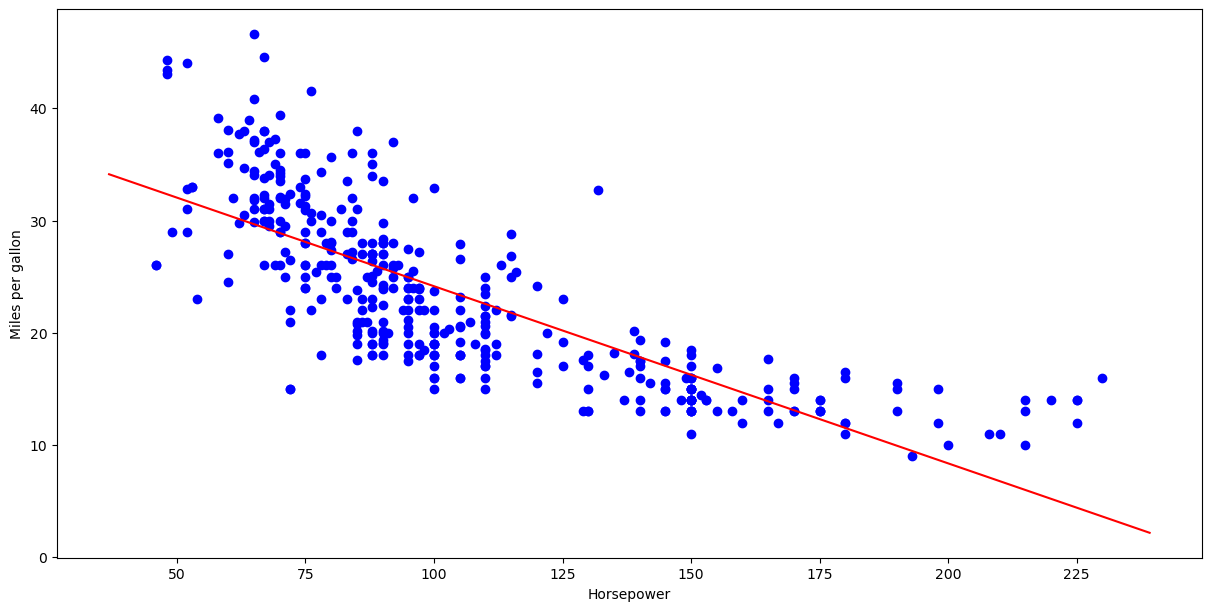

In [17]:
fig, ax = plt.subplots(figsize = (12, 6), constrained_layout=True)
ax.scatter(auto_df['horsepower'], auto_df['mpg'], color='blue')
abline(ax, test_result.params[0], test_result.params[1], color='red')
ax.set_xlabel('Horsepower')
ax.set_ylabel('Miles per gallon')
plt.show()


/var/folders/t2/6968g8md2c9g1mm1h0p9nxl588s4s1/T/ipykernel_72968/2854787409.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  line = test_result.params[0] + test_result.params[1] * auto_df['horsepower']


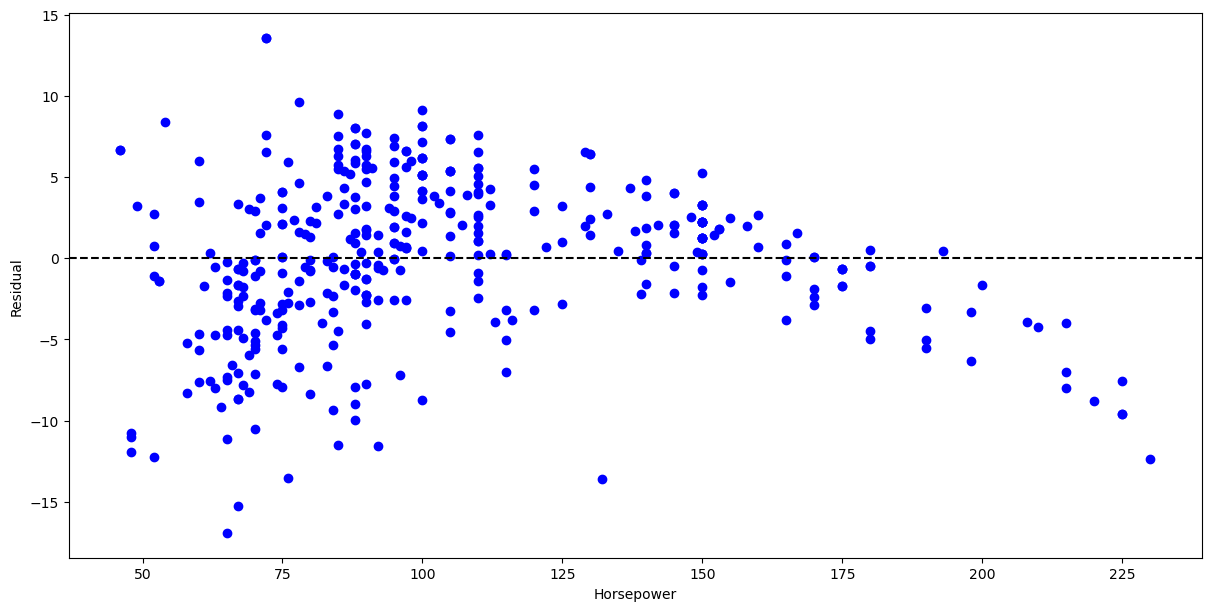

In [18]:
line = test_result.params[0] + test_result.params[1] * auto_df['horsepower']
residual_array = line - auto_df['mpg']

fig, ax = plt.subplots(figsize = (12, 6), constrained_layout=True)
ax.scatter(auto_df['horsepower'], residual_array, color='blue')
ax.set_ylabel('Residual')
ax.set_xlabel('Horsepower')
ax.axhline(0, ls = '--', color = 'black')
plt.show()

# Lab 2: Checking Colinearity and Correlations of Features

In [19]:
import seaborn as sb

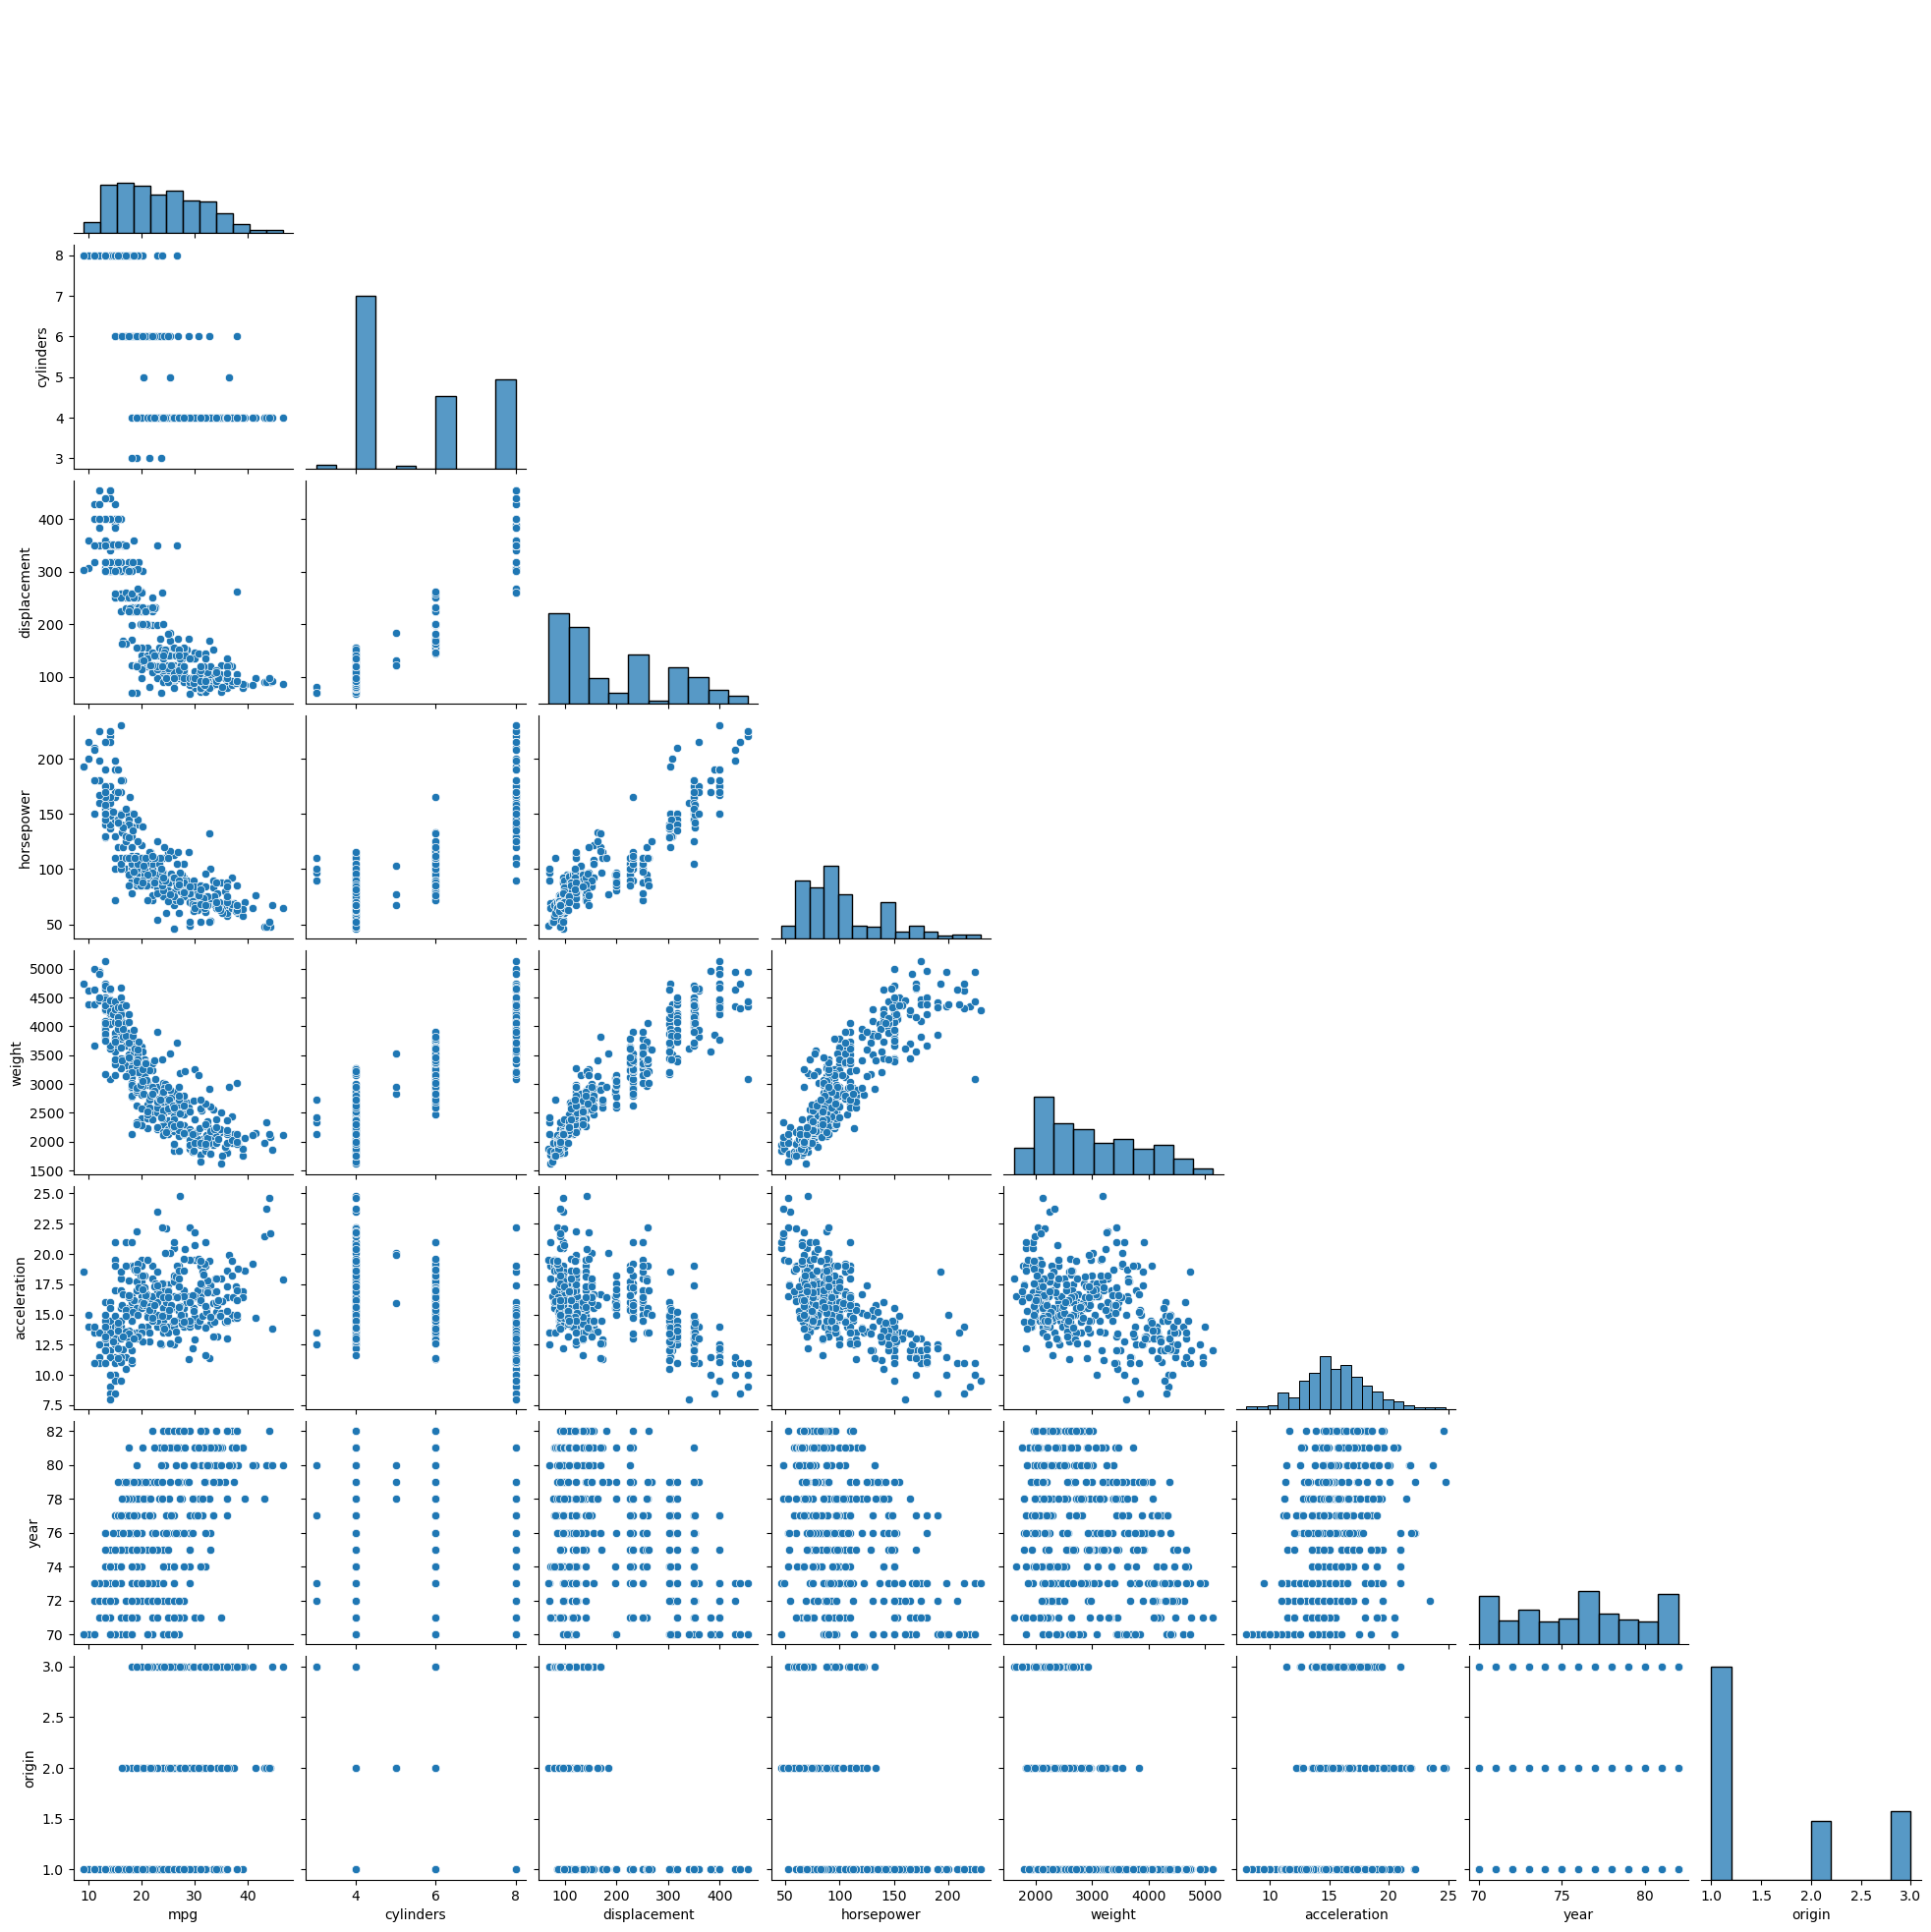

In [20]:
#using pairplot to see if other features show correlations
sb.pairplot(auto_df, corner = True)
plt.show()

In [21]:
#Selecting a few of the columns as features
cols = ['cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin']

features = auto_df[cols]

In [22]:
design = MS(cols)
design = design.fit(features)
X = design.transform (features)

In [23]:
#performing linear regression using multiple features 
multiple_linear_model = sm.OLS(y, X)
results = multiple_linear_model.fit()

In [24]:
summarize(results)

,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


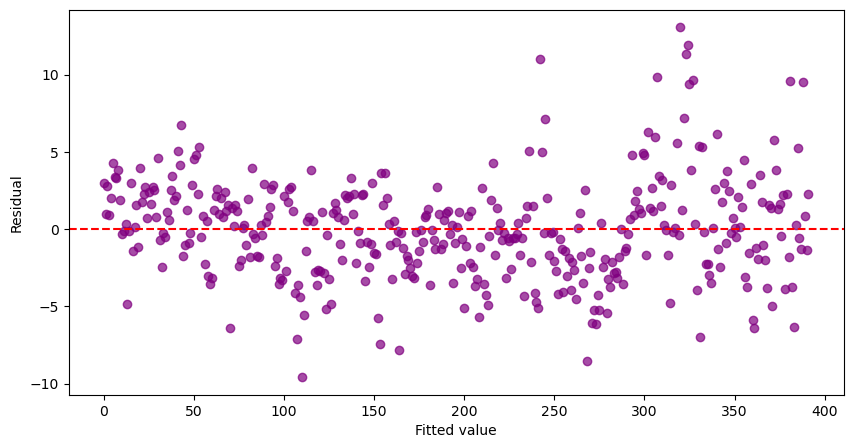

In [25]:
ax = plt.subplots (figsize =(10, 5))[1]
ax.scatter(np.arange(len(results.resid)), results.resid, alpha = 0.7, color = 'purple')
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline (0, c='red', ls='--')
plt.show()

# Checking for Feature impact on Variance

In [26]:
df = anova_lm(*[sm.OLS(y, D).fit() for D in design.build_sequence(features, anova_type='sequential')])
df.index = design.names
df

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
intercept,391.0,23818.993469,0.0,NaN,NaN,NaN
cylinders,390.0,9415.910391,1.0,14403.083079,1300.683788,2.806569e-126
displacement,389.0,8342.566366,1.0,1073.344025,96.929329,1.442524e-20
horsepower,388.0,7939.158297,1.0,403.408069,36.430140,3.700154e-09
weight,387.0,6963.433344,1.0,975.724953,88.113748,5.378297e-19
acceleration,386.0,6962.467273,1.0,0.966071,0.087242,7.678720e-01
year,385.0,4543.347025,1.0,2419.120249,218.460900,1.794078e-39
origin,384.0,4252.212530,1.0,291.134494,26.291171,4.665681e-07


Text(0, 0.5, 'Leverage ')

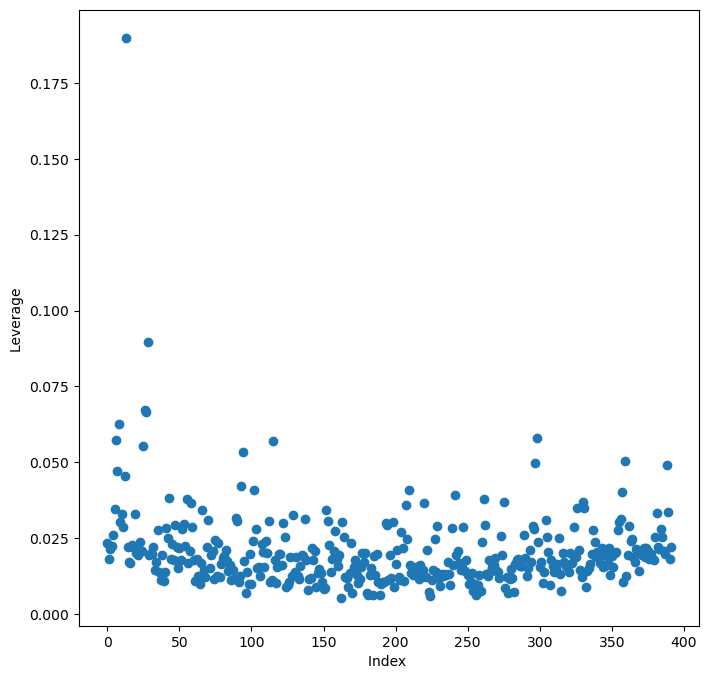

In [27]:
infl = results.get_influence ()
ax = plt.subplots (figsize =(8 ,8))[1]
ax.scatter(np.arange(X.shape [0]) , infl.hat_matrix_diag )
ax.set_xlabel ('Index ')
ax.set_ylabel ('Leverage ')

## Analysis on the Boston Dataset

In [28]:
boston_df = pd.read_csv('../Data/Boston.csv', index_col = 0)

In [29]:
boston_y = boston_df['medv']

In [30]:
X = MS([poly('lstat', degree=2) , 'age']).fit_transform(boston_df)
model3 = sm.OLS(boston_y, X)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


In [31]:
vals = [VIF(X, i) for i in range (1, X.shape [1])]
vif = pd.DataFrame ({'vif ':vals}, index=X.columns [1:])
vif

,vif
"poly(lstat, degree=2)[0]",1.606402
"poly(lstat, degree=2)[1]",1.064994
age,1.671397


# Heart Disease Dataset: Using KNN to Predict Heart Disease

In [32]:
heart_disease_df = pd.read_csv('../Data/Heart_disease.csv')

In [33]:
heart_disease_df.columns
heart_disease_df = heart_disease_df.dropna()

In [34]:
y = heart_disease_df['TenYearCHD']
X = heart_disease_df.drop(columns = ['TenYearCHD'])

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier

In [36]:
accuracy = []
matrix = {}

for i in np.arange(1, 10, 1):
    print(f'K = {i}')
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X, y)
    y_pred = knn.predict(X)
    #print(accuracy_score(y, y_pred))
    #print(confusion_matrix(y, y_pred))
    accuracy.append(accuracy_score(y, y_pred))
    matrix[i] = confusion_matrix(y, y_pred)
    #print(classification_report(y, y_pred))
    #print('---------------------------------')

K = 1
K = 2
K = 3
K = 4
K = 5
K = 6
K = 7
K = 8
K = 9


In [37]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      3101
           1       0.65      0.11      0.20       557

    accuracy                           0.86      3658
   macro avg       0.75      0.55      0.56      3658
weighted avg       0.83      0.86      0.81      3658



In [1]:
def plot_confusion_matrix(matrix):
    fig,ax = plt.subplots(1, 1)
    sb.heatmap(matrix, annot = True, fmt = 'd', ax = ax, 
               xticklabels = ['Heart Disease', 'No Heart Disease'], yticklabels= ['Heart Disease', 'No Heart Disease'])
    plt.savefig('plots/Heart_Disease_CM.png', dpi = 300)
    plt.show()

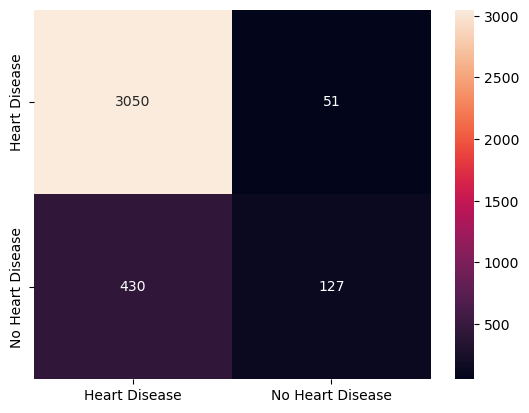

In [38]:
plot_confusion_matrix(matrix[5])